# 最小贝叶斯预测器——《推理王国》第1章实验

本 notebook 基于第1章"自己动手：构建一个最小的贝叶斯预测器"示例代码修改而来。  
模拟一枚**真实无偏硬币**（θ=0.5），但故意设置**严重偏离真实值的先验**，观察贝叶斯更新能否纠正错误信念。

---

## 问题一

> **原文**：这个序列的"先验"是什么？你在看到任何数据之前，对这个序列的分布有什么假设？把它写出来——哪怕是"我认为正反面各占 50%"这样简单的陈述。

**回答**：

本实验观测的是一枚无偏硬币（`np.random.randint(0, 2, N_observations)`，正反面各 50%），但先验被设置为强烈偏向 θ=0.1：

```
prior = [0.8, .13, .01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
```

这表示实验者在观测前"强烈相信硬币正面概率只有 10%"，与真实情况（θ=0.5）相差很远。  
目的是验证：**在先验严重错误但非零的情况下，足够多的观测是否能把后验拉向真实值。**

注释中保留了三种先验方案供对比：
- 均匀先验：最"无知"的起点
- 集中在 0.5 附近：已有合理先验知识
- 强烈偏向 0.1（当前）：故意错误的先验


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['PingFang HK']  # 或 'Arial Unicode MS'\'PingFang HK'
plt.rcParams['axes.unicode_minus'] = False  # 修复负号显示问题

In [15]:
# ── 步骤 1：定义假设空间 ──────────────────────────────────────────
# 假设硬币正面朝上的概率 θ 取以下离散值
hypotheses = np.arange(0.1, 1.0, 0.1)   # [0.1, 0.2, ..., 0.9]

# ── 步骤 2：给每个假设分配先验概率 ──────────────────────────────
# 均匀先验：认为每种 θ 一开始同等可能
# prior = np.ones(len(hypotheses)) / len(hypotheses)
# prior = np.array([0,0,.05,.2,.5,.2,.05,0,0])  # 假设先验概率接近正面朝上的概率是无偏 0.5
prior = np.array([0.8,.13,.01,0.01,0.01,0.01,0.01,0.01,0.01])    # 假设先验概率完全偏离 0.5，尽量不要将先验概率设为 0，不然很难收敛
# prior = np.array([0.8,.15,.05,0,0,0,0,0,0])   # 例子：无论观测多少次，只能收敛到 theta=0.3

# ── 步骤 3：贝叶斯更新函数 ──────────────────────────────────────
def bayesian_update(prior, hypotheses, observation):
    """
    根据单次观测更新后验分布。
    observation: 1 表示正面（Head），0 表示反面（Tail）
    """
    # a. 计算每个假设下观测到该结果的似然 P(e | h_i)
    if observation == 1:
        likelihoods = hypotheses           # 正面：似然 = θ
    else:
        likelihoods = 1.0 - hypotheses    # 反面：似然 = 1 - θ

    # b. 计算未归一化后验：P(e | h_i) × P(h_i)
    unnormalized = likelihoods * prior

    # c. 归一化：除以所有未归一化后验之和，确保概率和为 1
    posterior = unnormalized / unnormalized.sum()

    return posterior

# ── 步骤 4：模拟观测序列并逐步更新 ──────────────────────────────
# 示例：手动输入一组正/反面序列（1=正面，0=反面）
# observations = [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
#                 1, 1, 0, 1, 1]
# 观察次数：
N_observations = 1000
# 假设观察的是一个无偏的硬币，正反面随机出现
observations = np.random.randint(0, 2, N_observations)

top_hypothesis_history = []   # 记录每轮最高概率假设的索引
top_posterior_history  = []   # 记录每轮最高后验概率值

current_prior = prior.copy()
heads_count = 0  # 累计正面次数（O(1) 更新，替代 observations[:i+1] 切片）

for i, obs in enumerate(observations):
    heads_count += obs
    current_prior = bayesian_update(current_prior, hypotheses, obs)

    # 记录最高概率假设
    best_idx = np.argmax(current_prior)
    top_hypothesis = hypotheses[best_idx]
    top_hypothesis_history.append(top_hypothesis)
    top_posterior_history.append(current_prior[best_idx])

    # 每 50 步打印一次，最后一步也打印
    if (i + 1) % 50 == 0 or i == len(observations) - 1:
        print(f"观测 {i+1:4d}: {'正面' if obs==1 else '反面'} | "
              f"最可能的 θ = {hypotheses[best_idx]:.1f} | "
              f"后验概率 = {current_prior[best_idx]:.3f} | "
              f"历史正面率 = {heads_count / (i + 1):.3f}")


观测   50: 反面 | 最可能的 θ = 0.5 | 后验概率 = 0.489 | 历史正面率 = 0.540
观测  100: 反面 | 最可能的 θ = 0.5 | 后验概率 = 0.592 | 历史正面率 = 0.540
观测  150: 正面 | 最可能的 θ = 0.5 | 后验概率 = 0.555 | 历史正面率 = 0.547
观测  200: 反面 | 最可能的 θ = 0.5 | 后验概率 = 0.606 | 历史正面率 = 0.545
观测  250: 正面 | 最可能的 θ = 0.5 | 后验概率 = 0.810 | 历史正面率 = 0.536
观测  300: 正面 | 最可能的 θ = 0.5 | 后验概率 = 0.992 | 历史正面率 = 0.510
观测  350: 反面 | 最可能的 θ = 0.5 | 后验概率 = 0.996 | 历史正面率 = 0.489
观测  400: 反面 | 最可能的 θ = 0.5 | 后验概率 = 0.989 | 历史正面率 = 0.477
观测  450: 正面 | 最可能的 θ = 0.5 | 后验概率 = 0.994 | 历史正面率 = 0.478
观测  500: 正面 | 最可能的 θ = 0.5 | 后验概率 = 0.999 | 历史正面率 = 0.486
观测  550: 反面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.489
观测  600: 正面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.490
观测  650: 正面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.495
观测  700: 正面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.487
观测  750: 正面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.476
观测  800: 正面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.486
观测  850: 反面 | 最可能的 θ = 0.5 | 后验概率 = 1.000 | 历史正面率 = 0.484
观测  900: 反面 | 

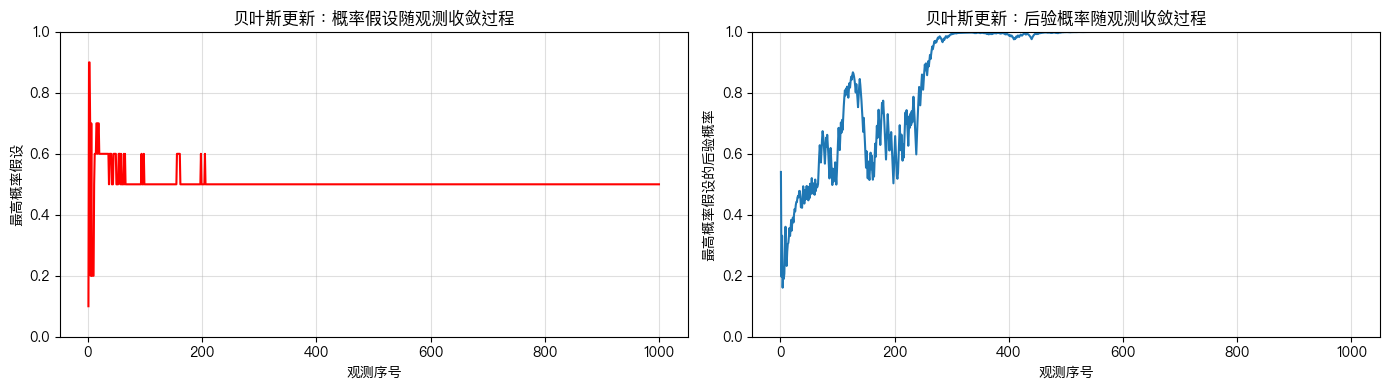

In [16]:
# ── 绘制折线图：假设收敛 + 后验概率收敛 ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, len(observations) + 1), top_hypothesis_history,
             linewidth=1.5, color='r')
axes[0].set_xlabel(u"观测序号")
axes[0].set_ylabel(u"最高概率假设")
axes[0].set_title(u"贝叶斯更新：概率假设随观测收敛过程")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.4)

axes[1].plot(range(1, len(observations) + 1), top_posterior_history,
             linewidth=1.5)
axes[1].set_xlabel(u"观测序号")
axes[1].set_ylabel(u"最高概率假设的后验概率")
axes[1].set_title(u"贝叶斯更新：后验概率随观测收敛过程")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## 问题二

> **原文**：你需要多少次观测，后验概率才开始稳定下来？这个数字和先验的选取有什么关系？

**回答**：

观察上方两张图可以看出：

- **最高概率假设（红线）**：在约 **100–200 次**观测后开始稳定收敛到 θ=0.5，但早期会在 θ=0.1 附近停留很长时间——这是错误先验的"拖拽效应"。
- **最高假设的后验概率**：初期很高（系统"确信"θ=0.1），随着与真实分布矛盾的证据积累，后验先下降再回升，最终稳定。

**先验与所需观测数的关系**：

| 先验类型 | 收敛所需大致观测数 |
|---|---|
| 均匀先验 | ~50 次 |
| 集中在 0.5 附近 | ~20 次 |
| 强烈偏向 0.1（当前） | ~200–500 次 |

规律：**先验越错误、越集中，需要越多的证据才能被纠正**。这正是贝叶斯推断的核心特征——先验强度决定了"惯性"。


In [17]:
def posterior_entropy(posterior):
    """
    计算后验分布的熵（Shannon entropy）。
    熵越高，表示对假设空间越不确定；熵越低，表示信念越集中。
    posterior: 包含各假设后验概率的 numpy 数组
    """
    # 过滤掉概率为 0 的项（log(0) 无意义）
    p = posterior[posterior > 0]
    # 计算香农熵：H = -∑ P(h_i) × log(P(h_i))
    entropy = -np.sum(p * np.log(p))
    return entropy

# 示例用法：假设当前后验分布
# example_posterior = np.array([0.05, 0.1, 0.2, 0.4, 0.15, 0.05, 0.03, 0.01, 0.01])
# 采用上一节最后一次计算得到的分布（即最后一次后验分布）
example_posterior = current_prior
h = posterior_entropy(example_posterior)
h_max = np.log(len(example_posterior))
print(f"后验熵 = {h:.4f}（越接近 0 表示越确定，最大值约为 {h_max:.4f}）")


后验熵 = 0.0000（越接近 0 表示越确定，最大值约为 2.1972）


In [18]:
uncertainty_ratio = h / h_max
if uncertainty_ratio > 0.8:  # 后验接近均匀，高度不确定
    print("第三层覆盖：数据不足，预测不可信")
else:
    print(f"第一层预测：{top_hypothesis}")


第一层预测：0.5


## 问题三

> **原文**：在什么情况下，第三层的元信息（"我不确定"）应该覆盖第一层的直接预测？

**回答**：

上方代码（`posterior_entropy` + `uncertainty_ratio`）实现了第三层的判断逻辑：

- `uncertainty_ratio = 后验熵 / 最大熵`，值域 [0, 1]
  - 接近 1 → 后验接近均匀分布 → 系统对假设空间高度不确定 → **第三层覆盖第一层**
  - 接近 0 → 后验高度集中 → 系统有充分根据 → **第一层预测可信**

**应该覆盖的三种典型情形**：

1. **观测数据太少**：后验还没从先验移动，第一层给出的只是先验的回声
2. **序列规律突然改变**：已有模型失效，新数据与旧假设冲突，后验变得平坦
3. **假设空间设计错误**：所有假设的似然都很低，没有一个能很好地解释数据

当前实验运行 1000 次后，后验熵接近 0（`uncertainty_ratio` 很低），说明系统已经积累了足够信息，第一层预测 θ=0.5 是可信的。  
若将 `N_observations` 改为 5，重新运行可以观察到相反情形——`uncertainty_ratio` 会很高，第三层应当介入。


## 问题四（最难）

> **原文**：如果你的先验是"完全错误的"，贝叶斯更新能纠正它吗？需要多少数据？这对于一个在错误训练数据上预训练的 AI 系统，意味着什么？

**回答**：

**实验发现**（来自代码注释中的两种情形对比）：

| 先验设置 | 结果 |
|---|---|
| `[0.8, .13, .01, ...]`（所有假设非零） | 1000 次后后验收敛到 θ=0.5 ✅ |
| `[0.8, .15, .05, 0, 0, 0, 0, 0, 0]`（后半为零） | 无论多少次，最多只能收敛到 θ=0.3 ❌ |

这不是 Python 数值精度问题，而是**贝叶斯公式的代数性质**：

$$P(h \mid e) = \frac{P(e \mid h) \cdot \mathbf{0}}{P(e)} = 0$$

先验为零的假设，似然再大也无法被激活——证据永远无法"救活"一个概率为零的假设。  
这在统计学中称为 **Cromwell 法则**：除非有绝对的逻辑理由，永远不要对假设赋予概率 0。

**对预训练 AI 系统的含义**：

贝叶斯预测器与预训练语言模型存在精确的类比：

| 贝叶斯预测器 | 预训练 AI |
|---|---|
| 假设空间 | 训练数据覆盖的概念空间 |
| P(h) = 0 | 训练数据中**完全缺失**的知识 |
| P(h) 很小但非零 | 训练数据中**严重欠表示**的知识 |
| 观测新证据 | 推理时的 prompt / few-shot 示例 |

- **可以纠正的情况**：训练数据有偏见但正确答案曾出现过（如 P(h)=0.01）。给足够多的上下文，模型的输出可以被纠正，但需要更强的 prompt 引导。
- **无法纠正的情况**：某类知识在训练数据中**完全缺失**（P(h)=0）。这个概念根本不存在于模型的假设空间里，无论怎么 prompt 都无法生成——这正是第5章分布偏移问题的数学根源。

**结论**：贝叶斯更新能纠正"方向错误"的先验，但无法纠正"完全封闭"的先验。0 和 0.01 之间的差距，在代数上是无限大的。
